In [1]:
import sys
sys.path.append('../../../')
sys.path.append('/home/sheida.rahnamai/GIT/HDN/')
import torch
from sklearn.cluster import HDBSCAN
# from lib.dataloader import CustomTestDataset
import tifffile as tiff

from math import pi

from numba import njit
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from glob import glob

In [2]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

dist_metric = ['euclidean']

num_clusters = 4
patch_size = (3,64,64)
mask_size = 1
label_size = 1
n_channel = 32
hierarchy_level = 3
model_versions = ['']

In [3]:
data_dir = "/group/jug/Sheida/Microsim/macrophage/"
key = "simulated_jrc_macrophage-2"

img = tiff.imread(data_dir + key + "_source.tif")
lbl = tiff.imread(data_dir + key + "_gt.tif")

num_stacks = img.shape[1]
indices = np.arange(num_stacks)
np.random.seed(42)  # For reproducibility
np.random.shuffle(indices)
# Calculate split sizes
train_size = int(0.7 * num_stacks)  # 70%
val_size = int(0.15 * num_stacks)  # 15%
test_size = num_stacks - train_size - val_size  # Remaining
# Split indices

test_indices = indices[train_size + val_size :]

# Split the stack along the second dimension (stacks)
test_images = img[:, test_indices, :, :]
test_ground_truth_image = lbl[:, test_indices, :, :]

In [4]:
import matplotlib.pyplot as plt
def plot_grid_with_colors(imgs, masks, pred, z, titles, colors):
    """
    Plots a grid with 2 rows (images and masks) and N columns (channels),
    using specific colors for each channel.

    Args:
        imgs (list): List of images, one per channel.
        masks (list): List of masks, one per channel.
        titles (list): Titles for each column/channel.
        colors (list): List of colors for each channel (e.g., ["cyan", "green", "magenta"]).
    """
    n_channels = masks.shape[0]
    fig, axes = plt.subplots(3, n_channels, figsize=(n_channels * 4, 12))
    
    for i in range(n_channels):
        # Use specific colormap for each channel
        cmap = LinearSegmentedColormap.from_list("custom", ["black", colors[i]])
        
        # Plot the image in the first row
        axes[0, i].imshow(imgs[i][z], cmap=cmap)
        axes[0, i].set_title(f"{titles[i]} - Image")
        axes[0, i].axis("off")
        
        # Plot the mask in the second row
        axes[1, i].imshow(masks[i][z], cmap=cmap)
        axes[1, i].set_title(f"{titles[i]} - Mask")
        axes[1, i].axis("off")
        
        axes[2, i].imshow(pred[i][z], cmap=cmap)
        axes[2, i].set_title(f"{titles[i]} - Prediction")
        axes[2, i].axis("off")
    
    plt.tight_layout()
    plt.show()

In [5]:
titles = ["nucleus", "mitochondria", "endoplasmic reticulum"]
colors = ["cyan", "green", "magenta"]

In [6]:
pred = np.zeros((9, 449, 449))
for i in range(9):
    pred[i, :, :] = tiff.imread("/group/jug/Sheida/HVAE/gmvae/confocal_mlp/seg/"+str(i)+".tif")
channel_1 = (pred == 1).astype(np.int32)  # Channel for label 1
channel_2 = (pred == 2).astype(np.int32)  # Channel for label 2
channel_3 = (pred == 3).astype(np.int32)  # Channel for label 3
three_channel_array = np.stack([channel_1, channel_2, channel_3], axis=0)  # Shape: (3, H, W)

In [7]:
cropped_gt = test_ground_truth_image[:, :, 31:512-32, 31:512-32]

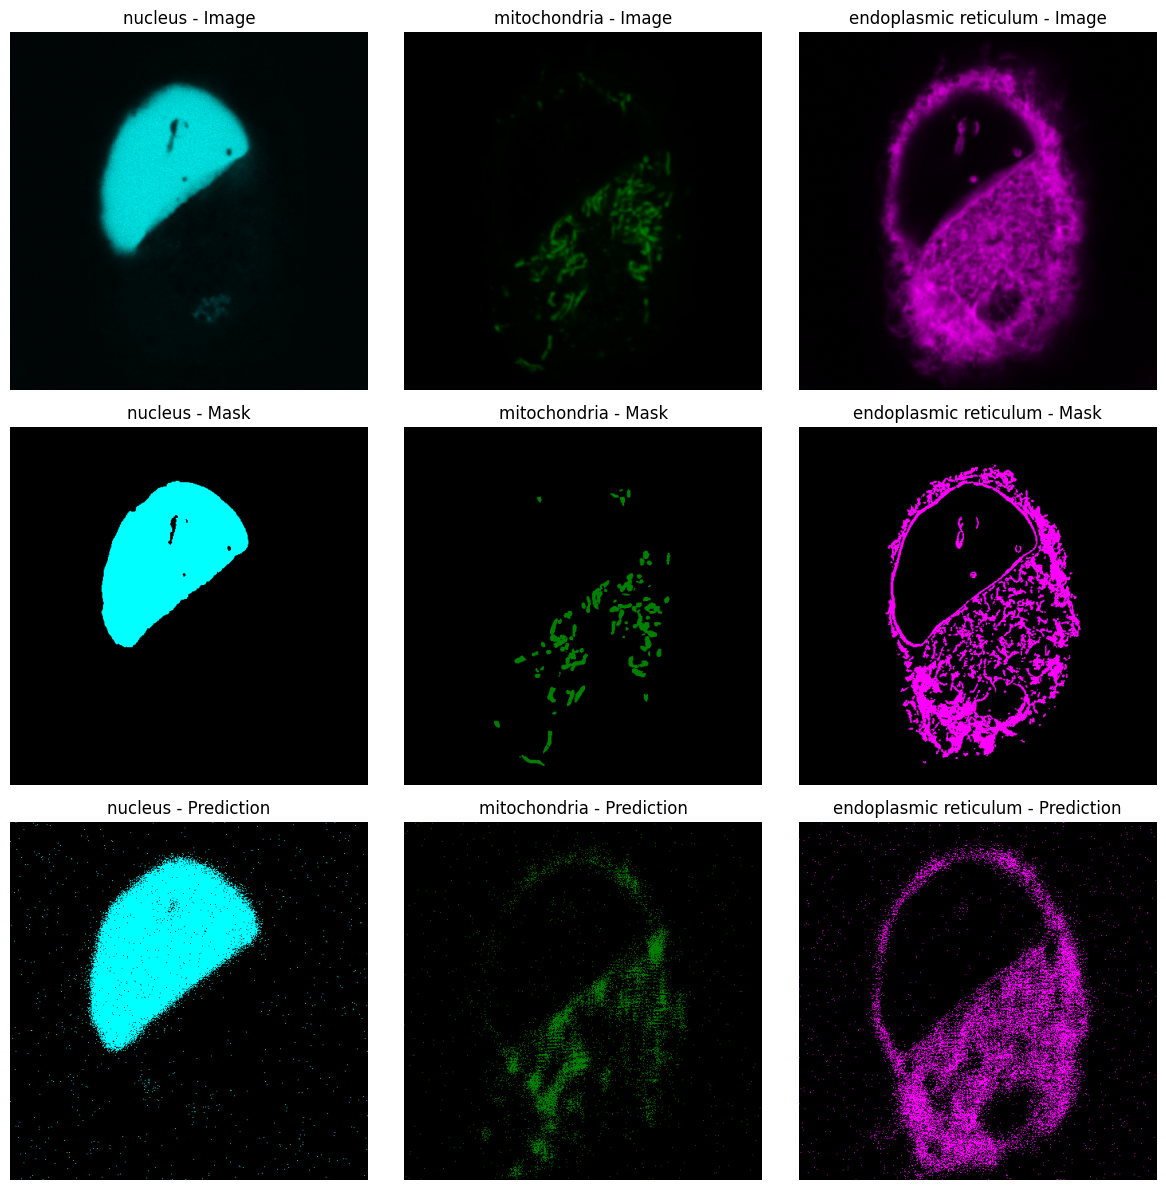

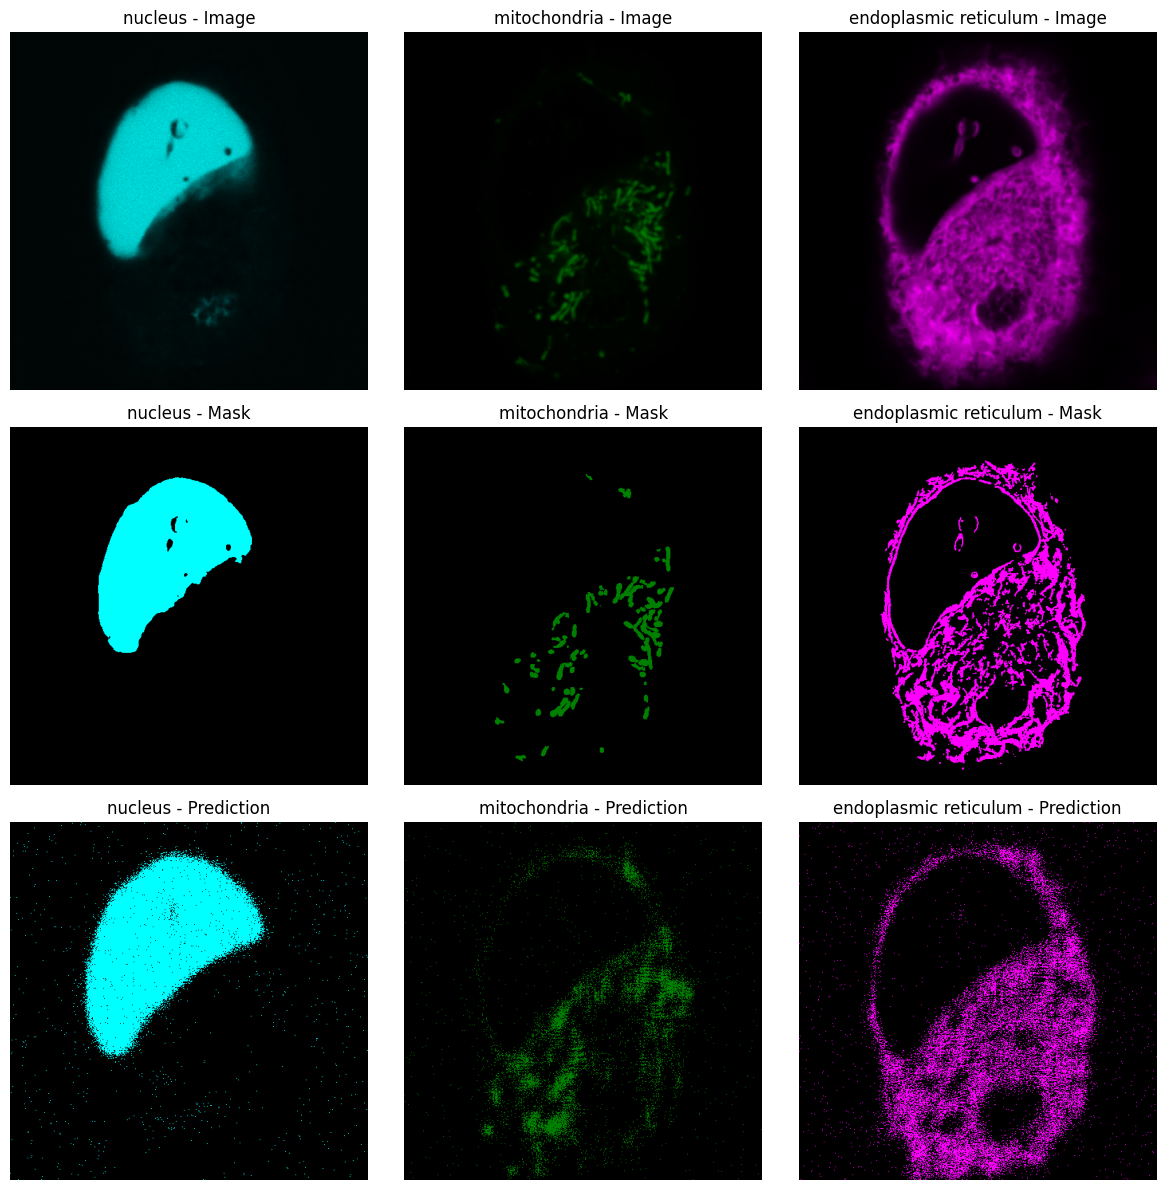

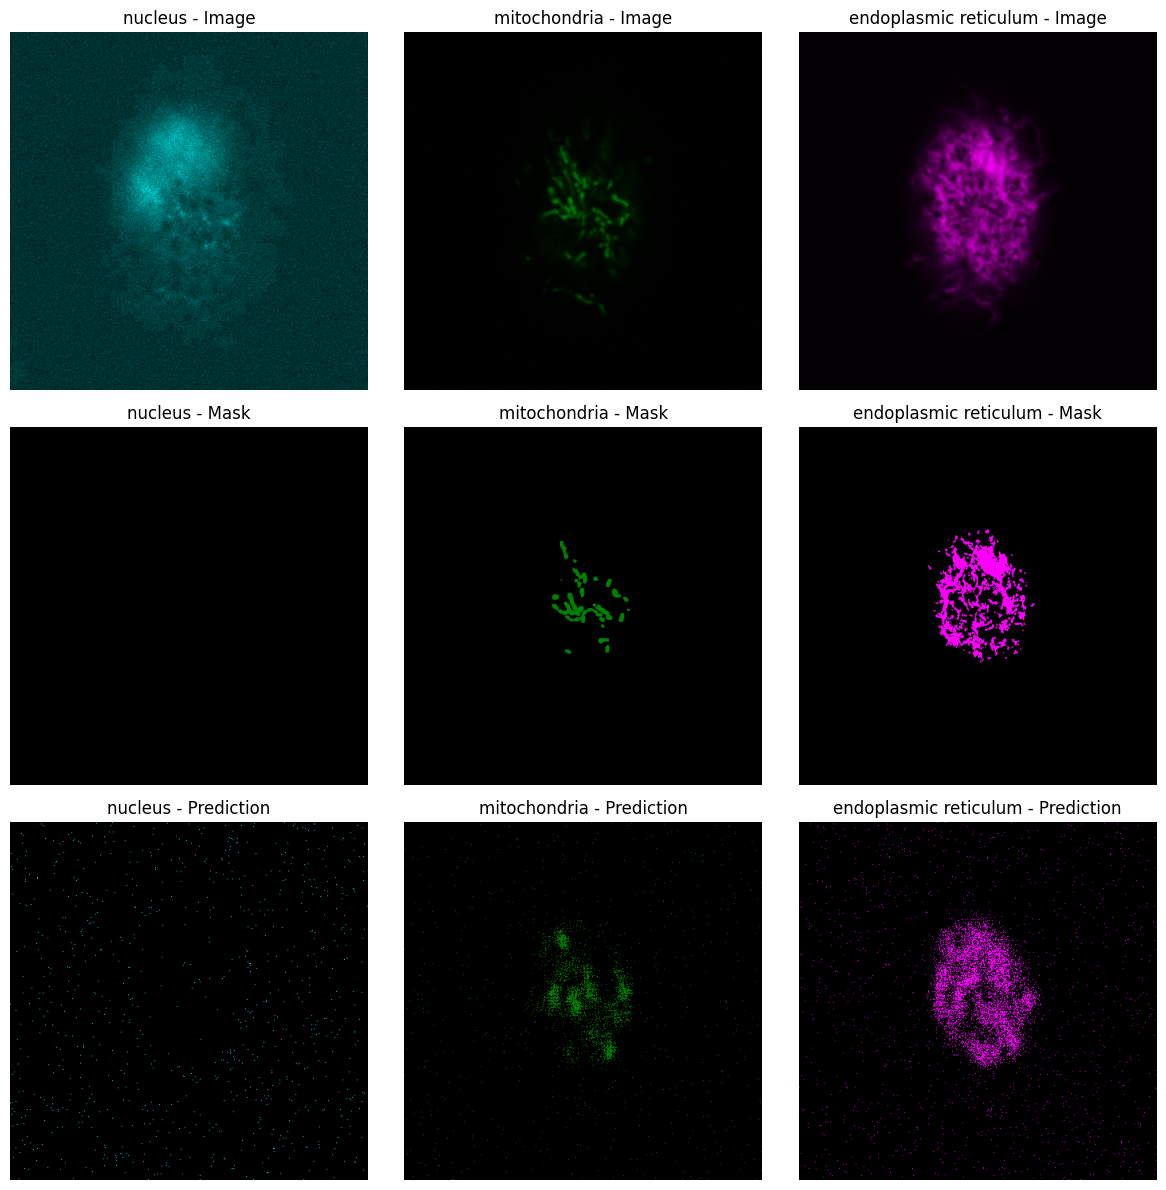

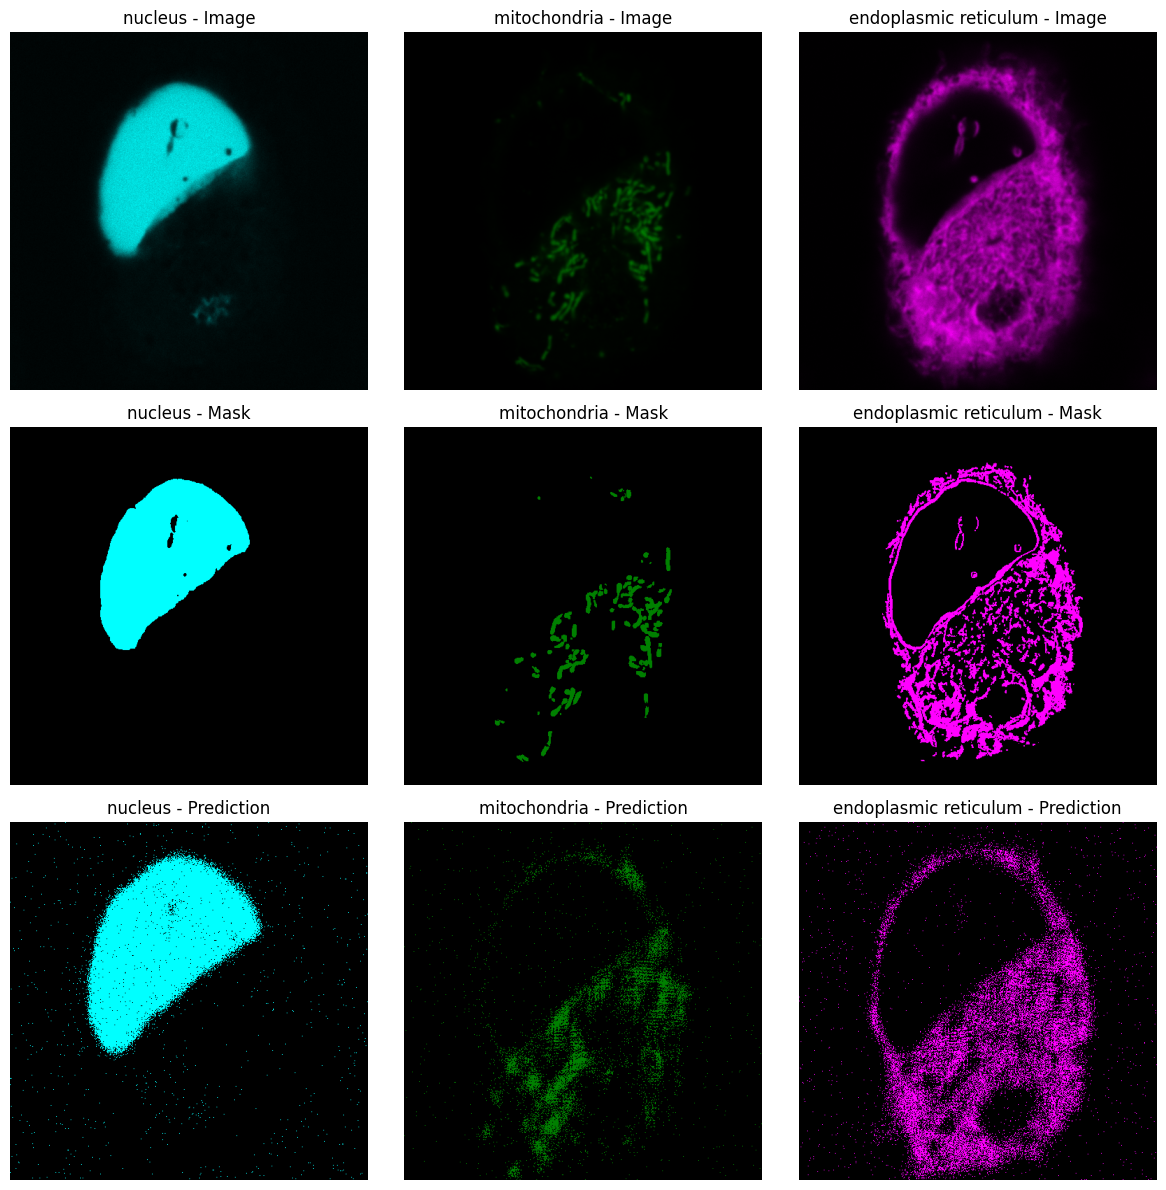

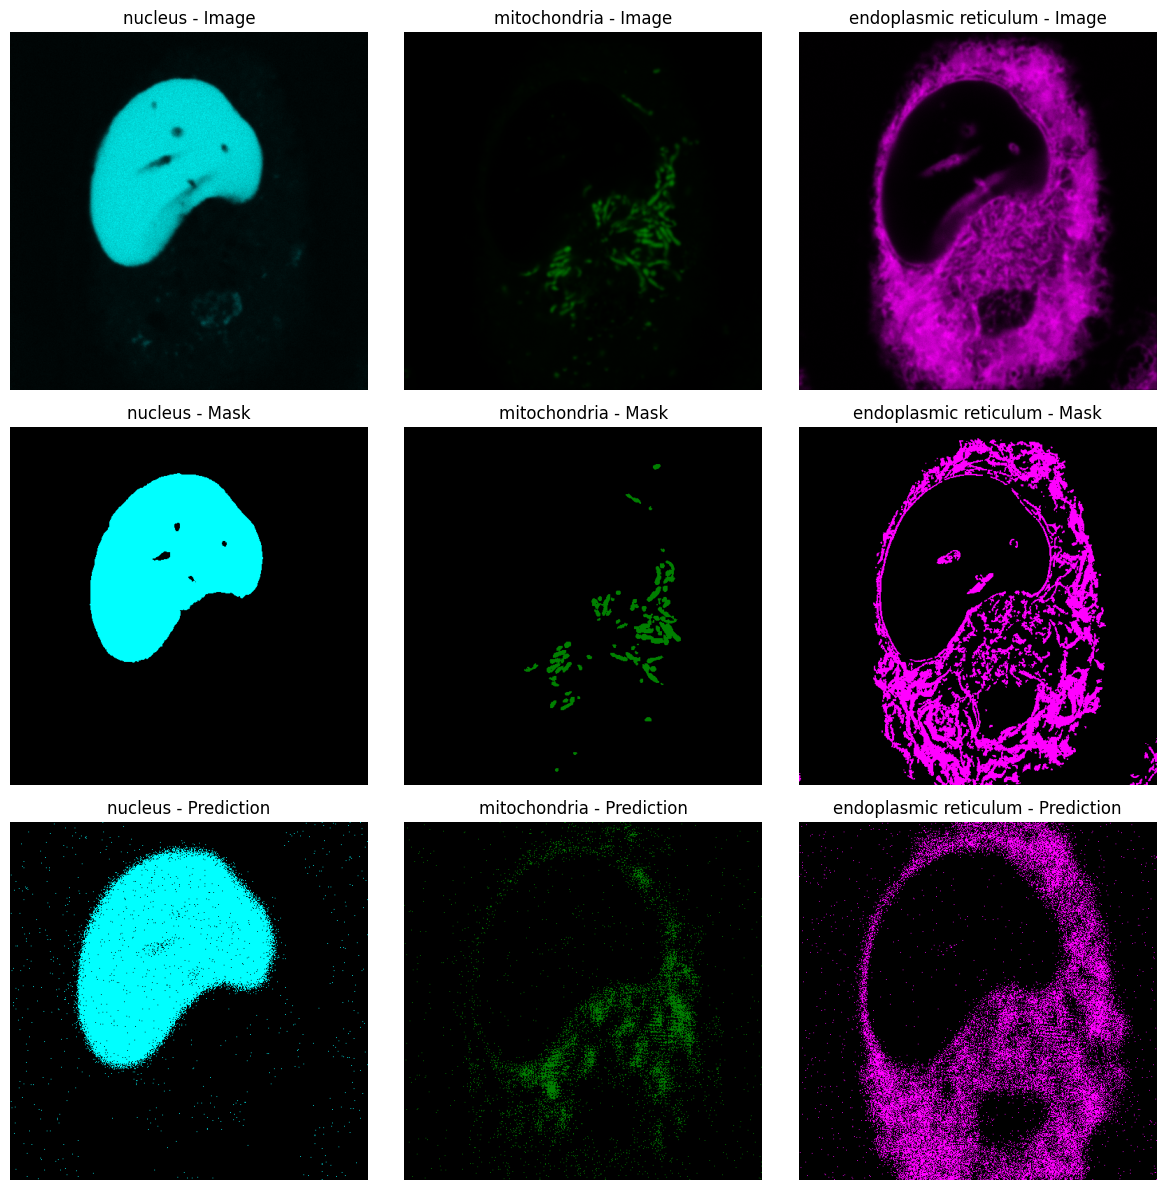

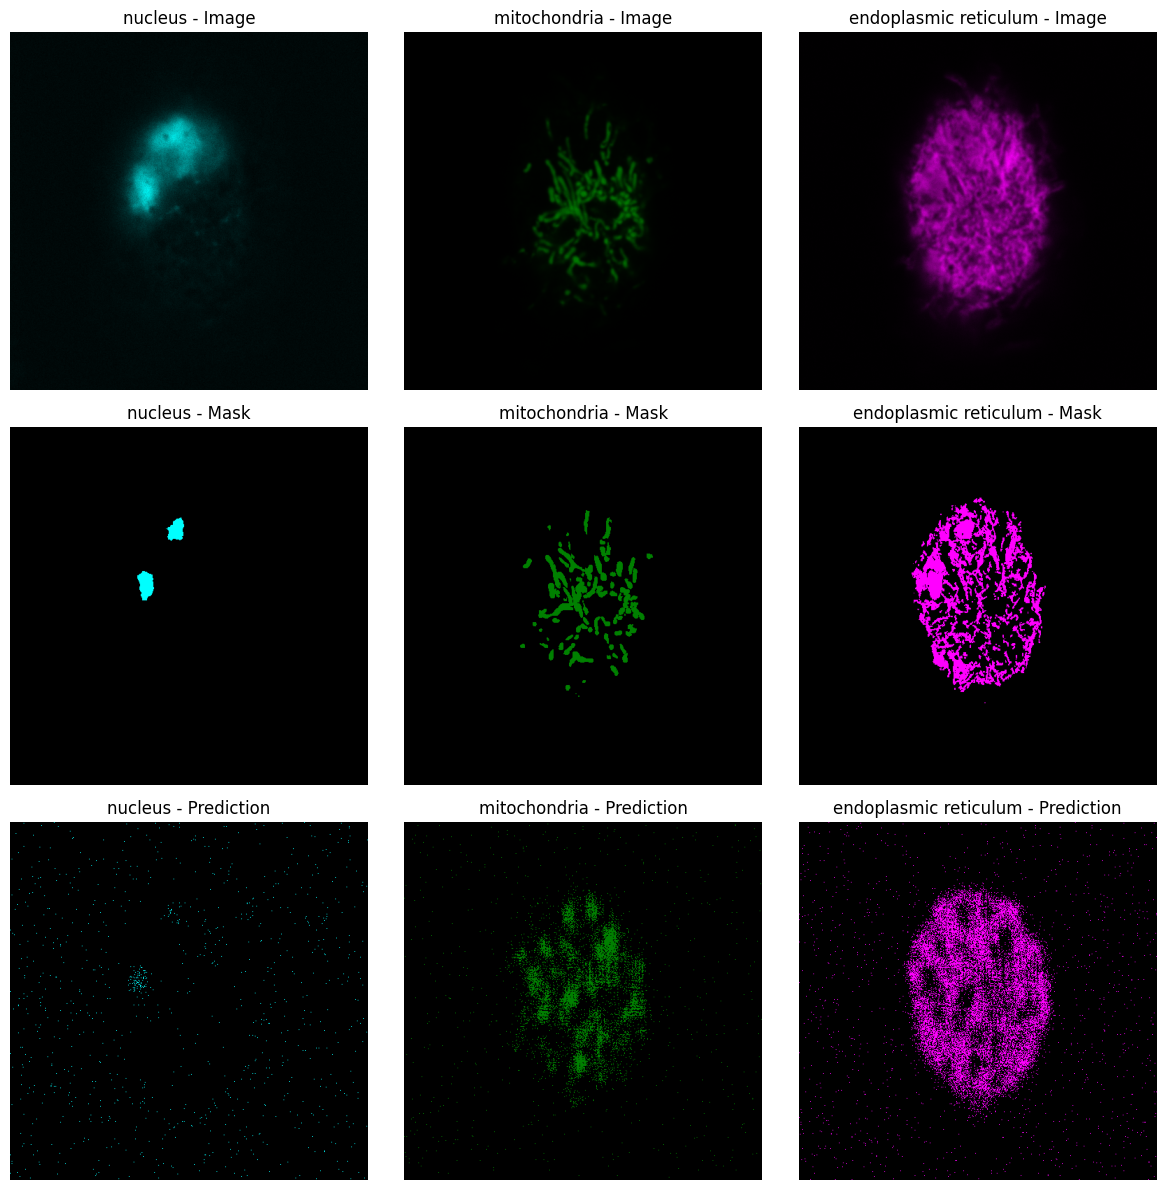

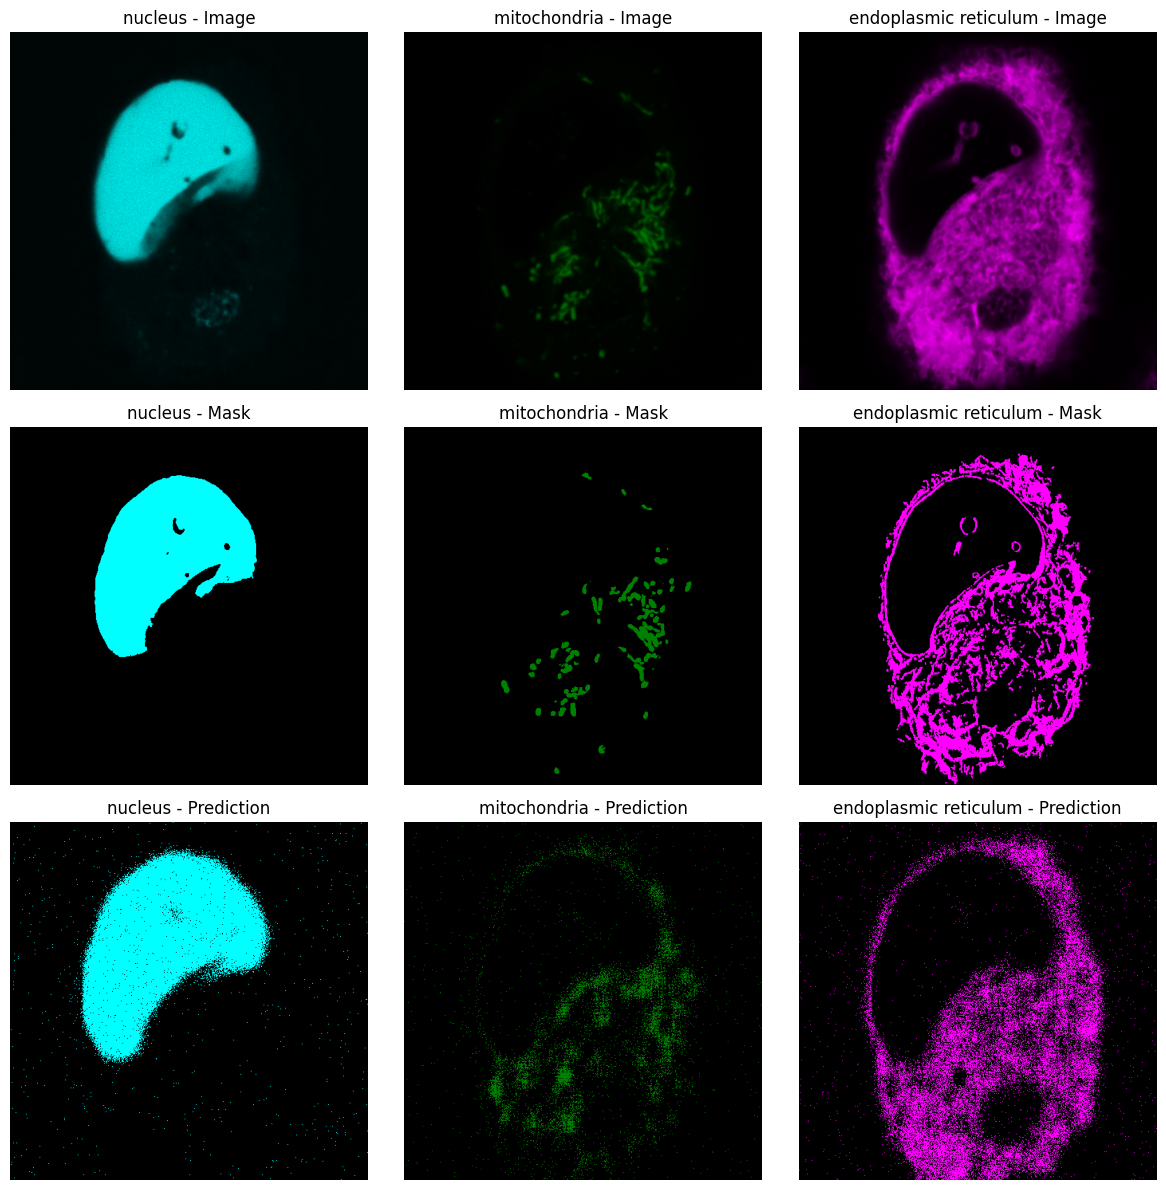

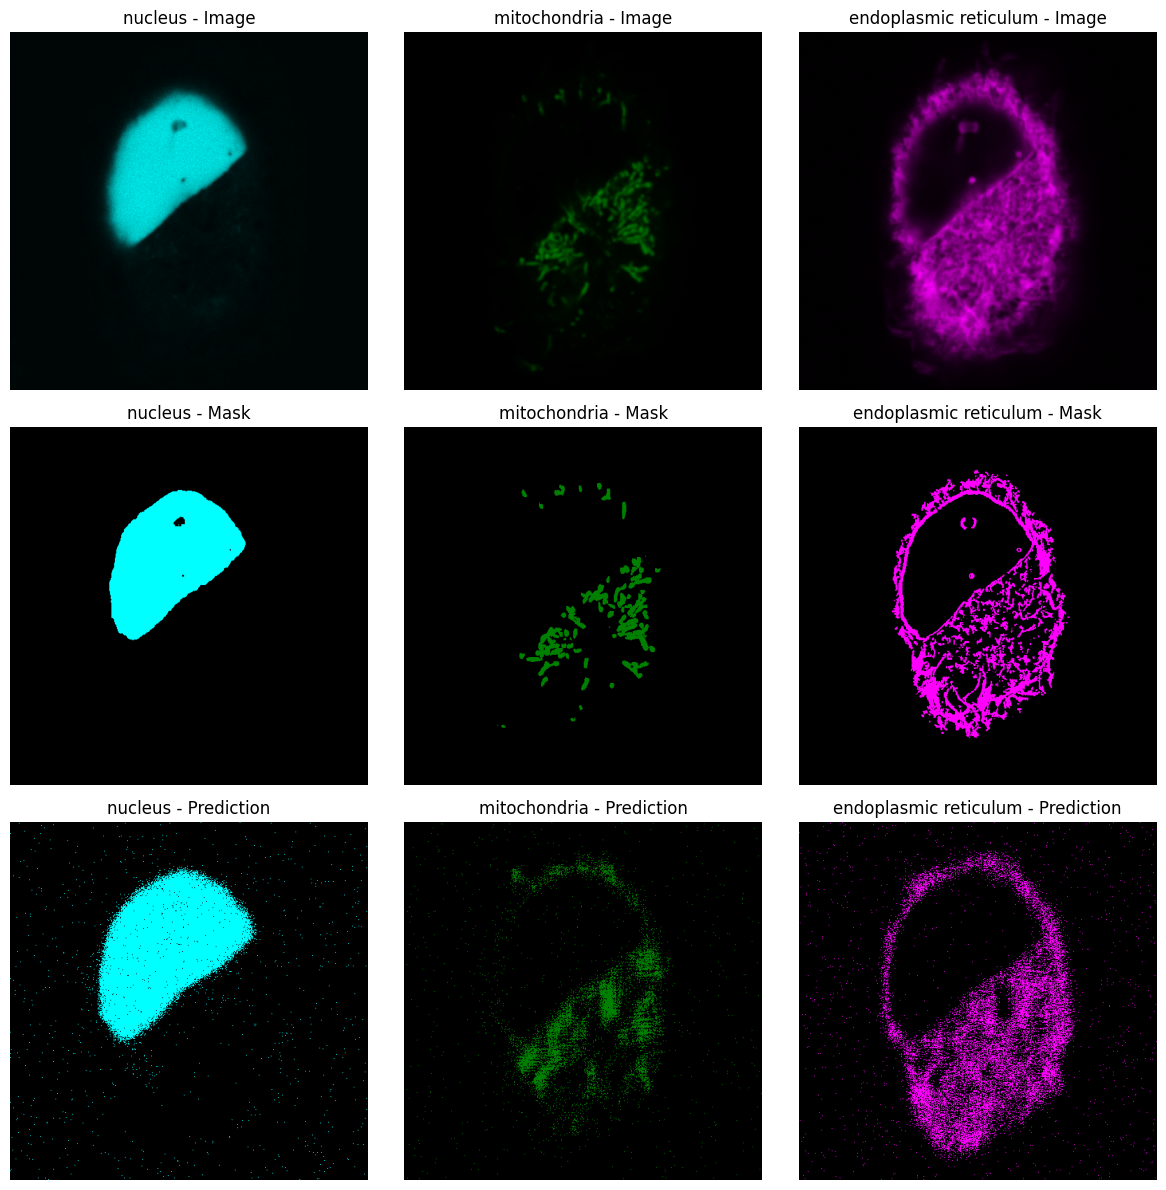

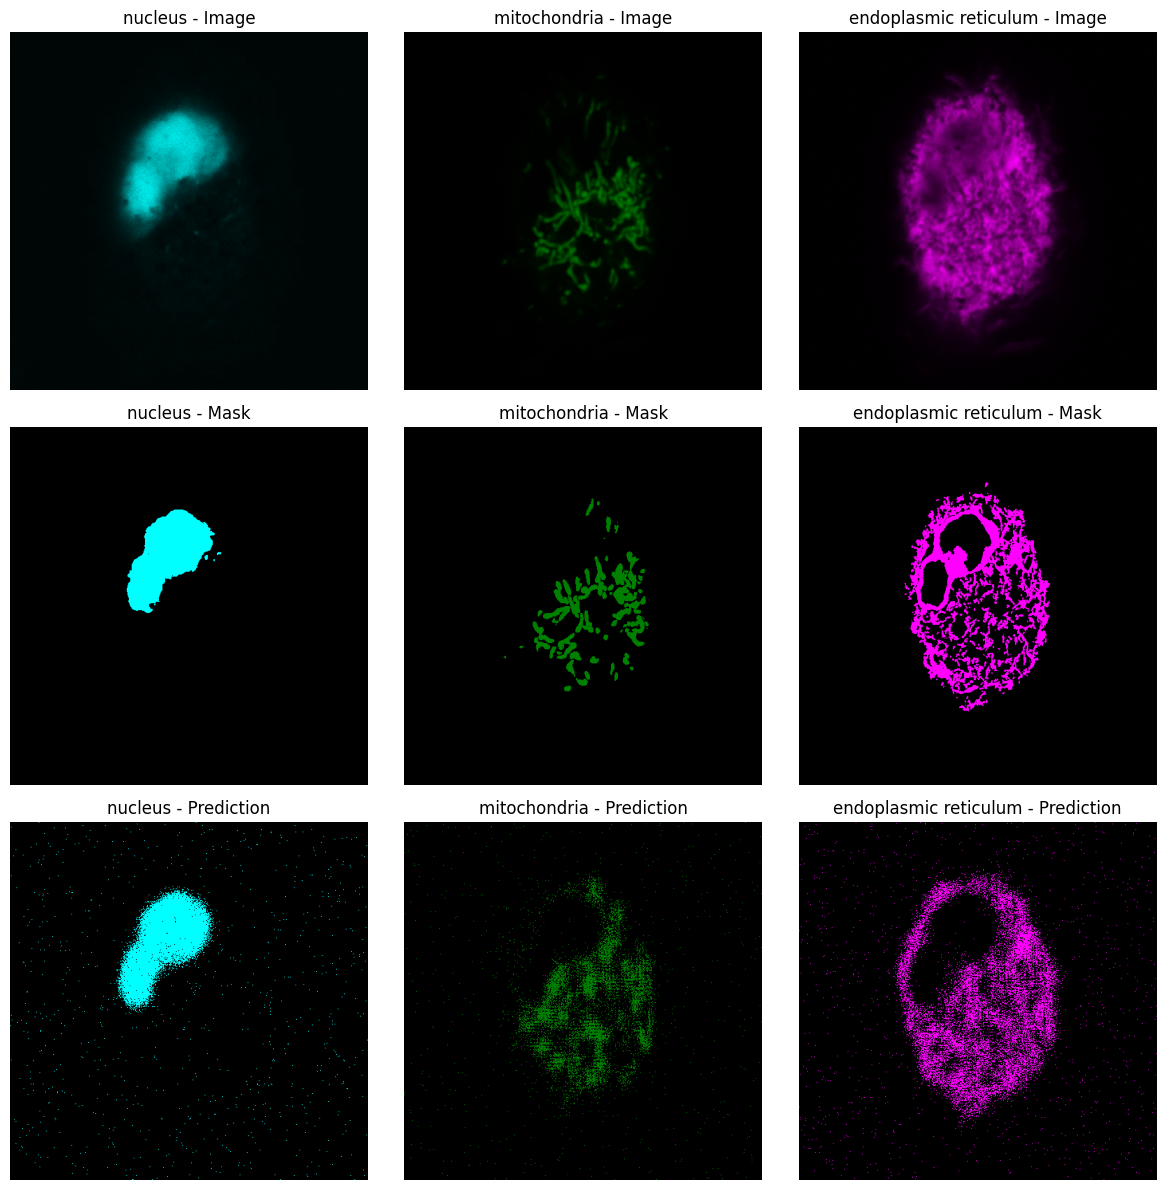

In [8]:
for i in range(9):
    plot_grid_with_colors(test_images, test_ground_truth_image, three_channel_array, i, titles, colors)

In [9]:
def compute_dice_for_labels(gt, pred, label):
    # Get unique labels from both gt and pred, excluding the ignore label
    # Create binary masks for the current label
    gt_mask = (gt == label)
    pred_mask = (pred == 1)
    
    # Compute intersection and union
    intersection = np.sum(gt_mask & pred_mask)
    union = np.sum(gt_mask) + np.sum(pred_mask)
    
    # Avoid division by zero
    if union == 0:
        dice = 1.0 if np.sum(gt_mask) == np.sum(pred_mask) == 0 else 0.0
    else:
        dice = 2 * intersection / union
    
    return dice

In [14]:
sum = 0
for z in range(9):
    for ch in range(3):
        print(f"z = {z} ch = {ch} {compute_dice_for_labels(cropped_gt[ch, z], three_channel_array[ch, z], ch+1)}")
        if ch == 2:
            sum += compute_dice_for_labels(cropped_gt[ch, z], three_channel_array[ch, z], ch+1)

z = 0 ch = 0 0.9442565326966441
z = 0 ch = 1 0.3024813420935128
z = 0 ch = 2 0.43228153937970465
z = 1 ch = 0 0.9424393913275141
z = 1 ch = 1 0.2979623649927625
z = 1 ch = 2 0.42914326189731006
z = 2 ch = 0 0.0
z = 2 ch = 1 0.2733632286995516
z = 2 ch = 2 0.3915937384444718
z = 3 ch = 0 0.9419286437165668
z = 3 ch = 1 0.301711079943899
z = 3 ch = 2 0.4176018156600681
z = 4 ch = 0 0.9569679592208266
z = 4 ch = 1 0.31248407643312104
z = 4 ch = 2 0.4737618764076941
z = 5 ch = 0 0.08024966562639323
z = 5 ch = 1 0.34210526315789475
z = 5 ch = 2 0.43655753683848403
z = 6 ch = 0 0.9403984620761972
z = 6 ch = 1 0.27663527452110964
z = 6 ch = 2 0.4657237070461645
z = 7 ch = 0 0.9414314992905565
z = 7 ch = 1 0.39159826170931916
z = 7 ch = 2 0.40073448402497247
z = 8 ch = 0 0.868531889290012
z = 8 ch = 1 0.37613206465665483
z = 8 ch = 2 0.4054276972196355


In [15]:
sum/9

0.42809173965761166

DSC mlp
nucleus: 0.827, mitochondria: 0.319, er: 0.431
DSC geo
nucleus: 0.829, mitochondria: 0.119, er: 0.513